# SmartTraining AI — Entraînement du modèle de risque

Classification supervisée binaire d'un apprenant à risque. Le dataset est synthétique, la cible `at_risk` est une *weak label* et les variables pouvant provoquer une fuite de cible sont exclues.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from pathlib import Path
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score, RocCurveDisplay

RANDOM_SEED = 42

In [2]:
DATASET_PATH = Path("../datasets/smarttraining_ai_dataset.csv")
df = pd.read_csv(DATASET_PATH)
print("Dimensions du dataset :", df.shape)
df.head()

Dimensions du dataset : (600, 17)


,learnerId,trainingId,progressPercentage,averageScore,completedLessons,totalLessons,completedQuizzes,totalQuizzes,totalEvents,totalTrainingsStarted,totalTrainingsCompleted,lessonCompletionRate,quizCompletionRate,scoreRatio,daysSinceLastActivity,avgEventsPerTraining,at_risk
0,1,1,20,23,2,10,1,3,1,1,0,0.2000,0.3333,0.23,34,1.0,1
1,2,8,93,96,9,10,3,3,20,2,0,0.9000,1.0000,0.96,3,10.0,0
2,3,10,53,57,4,7,2,4,12,4,0,0.5714,0.5000,0.57,4,3.0,0
3,4,3,66,52,6,9,1,1,10,4,2,0.6667,1.0000,0.52,17,2.5,0
4,5,8,84,74,6,7,2,2,24,4,2,0.8571,1.0000,0.74,5,6.0,0


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 600 entries, 0 to 599
Data columns (total 17 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   learnerId                600 non-null    int64  
 1   trainingId               600 non-null    int64  
 2   progressPercentage       600 non-null    int64  
 3   averageScore             600 non-null    int64  
 4   completedLessons         600 non-null    int64  
 5   totalLessons             600 non-null    int64  
 6   completedQuizzes         600 non-null    int64  
 7   totalQuizzes             600 non-null    int64  
 8   totalEvents              600 non-null    int64  
 9   totalTrainingsStarted    600 non-null    int64  
 10  totalTrainingsCompleted  600 non-null    int64  
 11  lessonCompletionRate     600 non-null    float64
 12  quizCompletionRate       600 non-null    float64
 13  scoreRatio               600 non-null    float64
 14  daysSinceLastActivity    6

In [4]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
learnerId,600.0,300.500000,173.349358,1.0,150.7500,300.5000,450.25,600.0
trainingId,600.0,5.470000,2.919470,1.0,3.0000,5.0000,8.00,10.0
progressPercentage,600.0,53.800000,25.817001,0.0,37.0000,57.0000,73.00,100.0
averageScore,600.0,64.386667,19.627087,20.0,52.7500,66.0000,78.00,100.0
completedLessons,600.0,4.275000,2.520575,0.0,2.0000,4.0000,6.00,12.0
totalLessons,600.0,7.921667,2.433530,4.0,6.0000,8.0000,10.00,12.0
completedQuizzes,600.0,1.361667,1.016162,0.0,1.0000,1.0000,2.00,4.0
totalQuizzes,600.0,2.488333,1.148359,1.0,1.0000,2.0000,4.00,4.0
totalEvents,600.0,11.923333,7.528075,0.0,6.0000,11.0000,16.00,30.0
totalTrainingsStarted,600.0,2.533333,1.136240,1.0,1.7500,3.0000,4.00,4.0


Répartition at_risk :
at_risk
0    434
1    166
Name: count, dtype: int64

Répartition en pourcentage :
at_risk
0    72.33
1    27.67
Name: proportion, dtype: float64


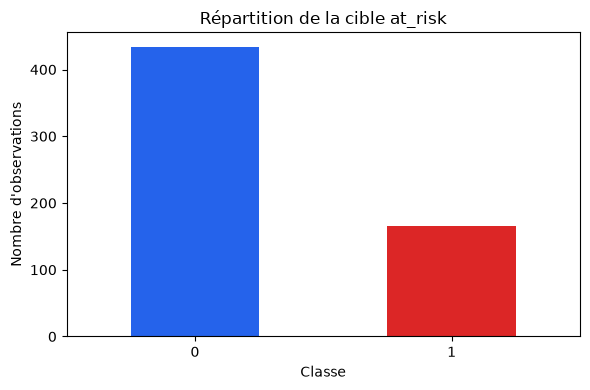

In [5]:
target_counts = df["at_risk"].value_counts().sort_index()
target_percentages = (df["at_risk"].value_counts(normalize=True).sort_index() * 100).round(2)
print("Répartition at_risk :")
print(target_counts)
print("\nRépartition en pourcentage :")
print(target_percentages)

plt.figure(figsize=(6, 4))
target_counts.plot(kind="bar", color=["#2563EB", "#DC2626"])
plt.title("Répartition de la cible at_risk")
plt.xlabel("Classe")
plt.ylabel("Nombre d'observations")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [6]:
missing_values = df.isna().sum().sort_values(ascending=False)
print("Nombre total de valeurs manquantes :", int(missing_values.sum()))
missing_values

Nombre total de valeurs manquantes : 0


learnerId                  0
trainingId                 0
progressPercentage         0
averageScore               0
completedLessons           0
totalLessons               0
completedQuizzes           0
totalQuizzes               0
totalEvents                0
totalTrainingsStarted      0
totalTrainingsCompleted    0
lessonCompletionRate       0
quizCompletionRate         0
scoreRatio                 0
daysSinceLastActivity      0
avgEventsPerTraining       0
at_risk                    0
dtype: int64

In [7]:
forbidden_columns = ["riskScore", "riskLevel", "riskFactors", "recommendations", "status", "atRiskTrainings"]
present_forbidden_columns = [column for column in forbidden_columns if column in df.columns]
print("Colonnes interdites présentes :", present_forbidden_columns)
assert not present_forbidden_columns, "Fuite de cible détectée."

Colonnes interdites présentes : []


In [8]:
target_column = "at_risk"
identifier_columns = ["learnerId", "trainingId"]
feature_columns = [
    "progressPercentage", "averageScore", "completedLessons", "totalLessons",
    "completedQuizzes", "totalQuizzes", "totalEvents", "totalTrainingsStarted",
    "totalTrainingsCompleted", "lessonCompletionRate", "quizCompletionRate",
    "scoreRatio", "daysSinceLastActivity", "avgEventsPerTraining",
]

assert not set(identifier_columns).intersection(feature_columns)
X = df[feature_columns]
y = df[target_column]
print("X shape :", X.shape)
print("y shape :", y.shape)
print("Identifiants exclus de X :", identifier_columns)
X.head()

X shape : (600, 14)
y shape : (600,)
Identifiants exclus de X : ['learnerId', 'trainingId']


,progressPercentage,averageScore,completedLessons,totalLessons,completedQuizzes,totalQuizzes,totalEvents,totalTrainingsStarted,totalTrainingsCompleted,lessonCompletionRate,quizCompletionRate,scoreRatio,daysSinceLastActivity,avgEventsPerTraining
0,20,23,2,10,1,3,1,1,0,0.2000,0.3333,0.23,34,1.0
1,93,96,9,10,3,3,20,2,0,0.9000,1.0000,0.96,3,10.0
2,53,57,4,7,2,4,12,4,0,0.5714,0.5000,0.57,4,3.0
3,66,52,6,9,1,1,10,4,2,0.6667,1.0000,0.52,17,2.5
4,84,74,6,7,2,2,24,4,2,0.8571,1.0000,0.74,5,6.0


In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_SEED, stratify=y
)
print("X_train :", X_train.shape)
print("X_test :", X_test.shape)
print("\nRépartition y_train (%) :")
print((y_train.value_counts(normalize=True).sort_index() * 100).round(2))
print("\nRépartition y_test (%) :")
print((y_test.value_counts(normalize=True).sort_index() * 100).round(2))

X_train : (480, 14)
X_test : (120, 14)

Répartition y_train (%) :
at_risk
0    72.29
1    27.71
Name: proportion, dtype: float64

Répartition y_test (%) :
at_risk
0    72.5
1    27.5
Name: proportion, dtype: float64


In [10]:
logistic_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(max_iter=1000, random_state=RANDOM_SEED)),
])
decision_tree_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("model", DecisionTreeClassifier(random_state=RANDOM_SEED)),
])
knn_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("model", KNeighborsClassifier()),
])
models = {
    "Logistic Regression": logistic_pipeline,
    "Decision Tree": decision_tree_pipeline,
    "KNN": knn_pipeline,
}
print("Pipelines :", list(models))

Pipelines : ['Logistic Regression', 'Decision Tree', 'KNN']


In [11]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_SEED)
cv_results = {}
for model_name, model in models.items():
    scores = cross_val_score(model, X_train, y_train, cv=cv, scoring="f1")
    cv_results[model_name] = scores
    print(model_name)
    print("F1 scores :", scores.round(3))
    print("F1 moyen :", round(scores.mean(), 3))
    print("Écart-type :", round(scores.std(), 3))
    print("-" * 50)

Logistic Regression
F1 scores : [0.824 0.784 0.963 0.868 0.84 ]
F1 moyen : 0.856
Écart-type : 0.06
--------------------------------------------------


Decision Tree
F1 scores : [0.778 0.72  0.787 0.741 0.786]
F1 moyen : 0.762
Écart-type : 0.027
--------------------------------------------------


KNN
F1 scores : [0.792 0.769 0.943 0.868 0.84 ]
F1 moyen : 0.842
Écart-type : 0.061
--------------------------------------------------


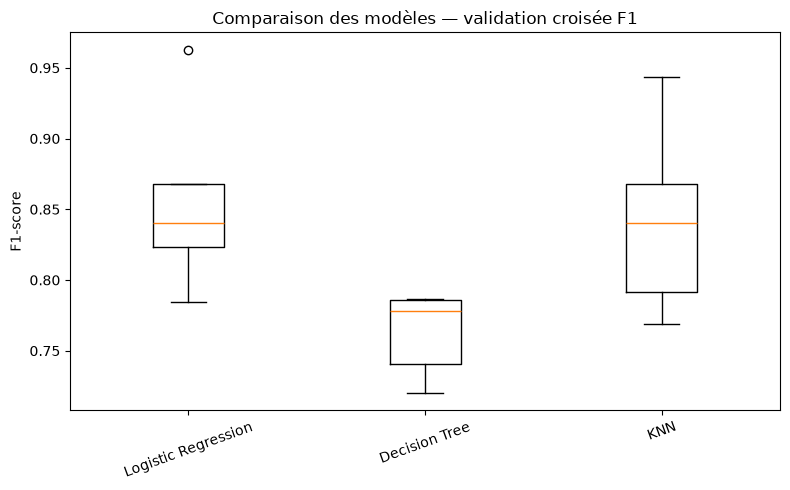

In [12]:
plt.figure(figsize=(8, 5))
plt.boxplot(cv_results.values(), tick_labels=cv_results.keys())
plt.title("Comparaison des modèles — validation croisée F1")
plt.ylabel("F1-score")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

In [13]:
test_results = []
for model_name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    report = classification_report(y_test, y_pred, output_dict=True, zero_division=0)
    y_pred_proba = model.predict_proba(X_test)[:, 1]
    test_results.append({
        "model": model_name,
        "accuracy": accuracy_score(y_test, y_pred),
        "precision_at_risk": report["1"]["precision"],
        "recall_at_risk": report["1"]["recall"],
        "f1_at_risk": report["1"]["f1-score"],
        "roc_auc": roc_auc_score(y_test, y_pred_proba),
    })

results_df = pd.DataFrame(test_results).sort_values("f1_at_risk", ascending=False)
results_df.round(3)

,model,accuracy,precision_at_risk,recall_at_risk,f1_at_risk,roc_auc
0,Logistic Regression,0.942,0.906,0.879,0.892,0.947
2,KNN,0.933,0.903,0.848,0.875,0.916
1,Decision Tree,0.833,0.676,0.758,0.714,0.810


In [14]:
for model_name, model in models.items():
    print("=" * 80)
    print(model_name)
    y_pred = model.predict(X_test)
    print(classification_report(y_test, y_pred, zero_division=0))
    print("Matrice de confusion :")
    print(confusion_matrix(y_test, y_pred))

Logistic Regression
              precision    recall  f1-score   support

           0       0.95      0.97      0.96        87
           1       0.91      0.88      0.89        33

    accuracy                           0.94       120
   macro avg       0.93      0.92      0.93       120
weighted avg       0.94      0.94      0.94       120

Matrice de confusion :
[[84  3]
 [ 4 29]]
Decision Tree
              precision    recall  f1-score   support

           0       0.90      0.86      0.88        87
           1       0.68      0.76      0.71        33

    accuracy                           0.83       120
   macro avg       0.79      0.81      0.80       120
weighted avg       0.84      0.83      0.84       120

Matrice de confusion :
[[75 12]
 [ 8 25]]
KNN
              precision    recall  f1-score   support

           0       0.94      0.97      0.95        87
           1       0.90      0.85      0.88        33

    accuracy                           0.93       120
   mac

Matrice de confusion — Logistic Regression
[[84  3]
 [ 4 29]]


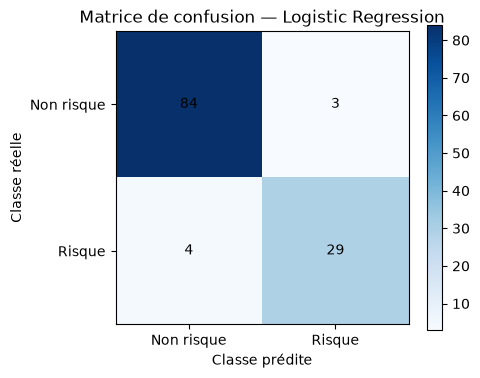

In [15]:
main_model_name = "Logistic Regression"
main_model = models[main_model_name]
y_pred_main = main_model.predict(X_test)
cm = confusion_matrix(y_test, y_pred_main)
print("Matrice de confusion —", main_model_name)
print(cm)

plt.figure(figsize=(5, 4))
plt.imshow(cm, cmap="Blues")
plt.title("Matrice de confusion — Logistic Regression")
plt.xlabel("Classe prédite")
plt.ylabel("Classe réelle")
plt.xticks([0, 1], ["Non risque", "Risque"])
plt.yticks([0, 1], ["Non risque", "Risque"])
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm[i, j], ha="center", va="center")
plt.colorbar()
plt.tight_layout()
plt.show()

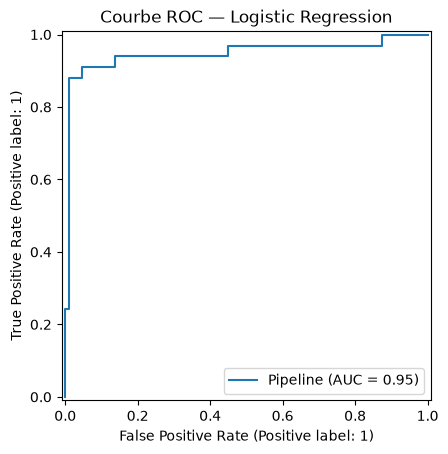

ROC AUC : 0.947


In [16]:
RocCurveDisplay.from_estimator(main_model, X_test, y_test)
plt.title("Courbe ROC — Logistic Regression")
plt.show()
y_pred_proba_main = main_model.predict_proba(X_test)[:, 1]
print("ROC AUC :", round(roc_auc_score(y_test, y_pred_proba_main), 3))

In [17]:
param_grid = {
    "model__C": [0.01, 0.1, 1, 10],
    "model__class_weight": [None, "balanced"],
}
grid_search = GridSearchCV(
    logistic_pipeline, param_grid=param_grid, scoring="f1", cv=cv, n_jobs=-1
)
grid_search.fit(X_train, y_train)
print("Meilleurs paramètres :", grid_search.best_params_)
print("Meilleur score CV F1 :", round(grid_search.best_score_, 3))

Meilleurs paramètres : {'model__C': 1, 'model__class_weight': None}
Meilleur score CV F1 : 0.856


In [18]:
best_model = grid_search.best_estimator_
y_pred_best = best_model.predict(X_test)
print(classification_report(y_test, y_pred_best, zero_division=0))
print("Matrice de confusion :")
print(confusion_matrix(y_test, y_pred_best))
y_pred_proba_best = best_model.predict_proba(X_test)[:, 1]
print("ROC AUC :", round(roc_auc_score(y_test, y_pred_proba_best), 3))

              precision    recall  f1-score   support

           0       0.95      0.97      0.96        87
           1       0.91      0.88      0.89        33

    accuracy                           0.94       120
   macro avg       0.93      0.92      0.93       120
weighted avg       0.94      0.94      0.94       120

Matrice de confusion :
[[84  3]
 [ 4 29]]
ROC AUC : 0.947


In [19]:
sample_learner = pd.DataFrame([{
    "progressPercentage": 25, "averageScore": 42, "completedLessons": 1,
    "totalLessons": 8, "completedQuizzes": 0, "totalQuizzes": 3,
    "totalEvents": 2, "totalTrainingsStarted": 1, "totalTrainingsCompleted": 0,
    "lessonCompletionRate": 0.125, "quizCompletionRate": 0.0,
    "scoreRatio": 0.42, "daysSinceLastActivity": 28, "avgEventsPerTraining": 2.0,
}])
prediction = int(best_model.predict(sample_learner)[0])
probability = float(best_model.predict_proba(sample_learner)[0][1])
print("Prédiction at_risk :", prediction)
print("Probabilité de risque :", round(probability, 3))
print("Interprétation :", "apprenant prédit à risque" if prediction else "apprenant non prédit à risque")

Prédiction at_risk : 1
Probabilité de risque : 0.833
Interprétation : apprenant prédit à risque


In [20]:
logistic_model = best_model.named_steps["model"]
coefficients = pd.DataFrame({
    "feature": feature_columns,
    "coefficient": logistic_model.coef_[0],
})
coefficients["abs_coefficient"] = coefficients["coefficient"].abs()
coefficients.sort_values("abs_coefficient", ascending=False).reset_index(drop=True)

,feature,coefficient,abs_coefficient
0,daysSinceLastActivity,0.672542,0.672542
1,totalEvents,-0.593483,0.593483
2,progressPercentage,-0.551112,0.551112
3,completedLessons,-0.428433,0.428433
4,completedQuizzes,0.383336,0.383336
5,avgEventsPerTraining,-0.373205,0.373205
6,averageScore,-0.365654,0.365654
7,scoreRatio,-0.365654,0.365654
8,totalQuizzes,-0.168836,0.168836
9,totalLessons,0.122288,0.122288


## Sauvegarde du modèle IA

Le pipeline complet est sauvegardé avec son prétraitement, la liste ordonnée des features et les métadonnées méthodologiques.

In [21]:
import json
import joblib
from datetime import datetime, timezone

MODELS_DIR = Path("../models")
MODELS_DIR.mkdir(parents=True, exist_ok=True)
MODEL_PATH = MODELS_DIR / "risk_prediction_pipeline.joblib"
METADATA_PATH = MODELS_DIR / "model_metadata.json"

joblib.dump(best_model, MODEL_PATH)

best_report = classification_report(y_test, y_pred_best, output_dict=True, zero_division=0)
metadata = {
    "project": "SmartTraining AI",
    "model_version": "1.0.0",
    "model_name": "LogisticRegression",
    "problem_type": "binary_classification",
    "target": "at_risk",
    "target_description": {"0": "apprenant non à risque", "1": "apprenant à risque"},
    "label_type": "weak_label",
    "label_warning": (
        "La cible at_risk est construite par règles pour le prototype PFE. "
        "Un modèle de production devra être réentraîné avec des résultats réels observés."
    ),
    "features": feature_columns,
    "identifier_columns_excluded": identifier_columns,
    "excluded_columns_to_avoid_target_leakage": [
        "riskScore", "riskLevel", "riskFactors", "recommendations", "status", "atRiskTrainings"
    ],
    "training_method": {
        "train_test_split": "80/20",
        "stratify": True,
        "cross_validation": "StratifiedKFold n_splits=5",
        "hyperparameter_search": "GridSearchCV",
        "main_scoring": "f1",
        "random_seed": RANDOM_SEED,
    },
    "best_params": grid_search.best_params_,
    "best_cv_f1": float(grid_search.best_score_),
    "test_metrics": {
        "accuracy": float(accuracy_score(y_test, y_pred_best)),
        "precision_at_risk": float(best_report["1"]["precision"]),
        "recall_at_risk": float(best_report["1"]["recall"]),
        "f1_at_risk": float(best_report["1"]["f1-score"]),
        "roc_auc": float(roc_auc_score(y_test, y_pred_proba_best)),
    },
    "created_at": datetime.now(timezone.utc).isoformat(),
}

with METADATA_PATH.open("w", encoding="utf-8") as json_file:
    json.dump(metadata, json_file, indent=4, ensure_ascii=False)

print("Modèle sauvegardé :", MODEL_PATH)
print("Métadonnées sauvegardées :", METADATA_PATH)
print("Taille du pipeline (octets) :", MODEL_PATH.stat().st_size)

Modèle sauvegardé : ..\models\risk_prediction_pipeline.joblib
Métadonnées sauvegardées : ..\models\model_metadata.json
Taille du pipeline (octets) : 2673


## Conclusion

- Le problème est une classification supervisée binaire.
- La cible `at_risk` est une *weak label*.
- Logistic Regression est le modèle principal pour son interprétabilité.
- Decision Tree et KNN servent de comparaisons.
- L'évaluation utilise notamment le rappel, la précision, le F1-score, la matrice de confusion et ROC AUC.
- Les identifiants et les variables à fuite de cible sont exclus de l'entraînement.
- Ce prototype devra être réentraîné sur des données réelles avant un usage de production.